# Example 11: Lunar Lander Navigation with IMU, Altimeter, Crater Bearings, and LunaNet

This tutorial simulates powered-descent navigation for a lunar lander. It builds on the surface-rover example but changes both the motion and the sensor suite: the vehicle descends rapidly, carries a nadir altimeter, observes crater landmarks, and receives LunaNet/LCRNS pseudoranges.

LuPNT runs the estimator as a `LanderNavApp` hosted by a `Lander` agent. The filter is a multiplicative EKF (MEKF): attitude is represented by a unit quaternion, while the covariance carries a small three-parameter attitude error. This avoids directly adding corrections to a quaternion and then violating the unit-norm constraint.

The main measurement ideas are:

$$
z_{alt}=U-h_{DEM}(E,N)+\epsilon, \qquad
\mathbf z_{bearing}=\pi(R_{nb}(\mathbf p_{crater}-\mathbf r_{lander}))+\epsilon,
$$

plus LunaNet pseudorange for absolute range and clock information. Crater bearings are especially valuable because they make yaw observable during descent.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import plotly.graph_objects as go

import os, sys
from pathlib import Path

# Use THIS repo's pylupnt/data, not a stale copy on a global PYTHONPATH (~/.zshrc) or kernelspec.
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt

# pylupnt.plot (imported by pylupnt) sets the global font to cmr10, which lacks some glyphs (e.g. σ);
# use a standard font so all labels render.
import matplotlib as mpl

mpl.rcParams["font.family"] = "DejaVu Sans"

np.random.seed(0)

# Host heavy interactive figures on lupnt-doc-assets instead of embedding them.
import sys as _sys
from pathlib import Path as _Path

for _p in [_Path.cwd(), *_Path.cwd().parents]:
    if (_p / "python" / "examples" / "_doc_assets.py").exists():
        _sys.path.insert(0, str(_p / "python" / "examples"))
        break
from _doc_assets import embed_plotly, embed_cesium_scene

[00.01][PyLuPNT] Initializing


## 1. Load the digital elevation model

`pnt.load_lola_dem(lat, lon)` picks the nearest NASA PGDA product-78 site, downloads/caches its
5 m/pixel GeoTIFF, and returns a cropped, downsampled `LunarDem`. We use **Site01 (Connecting Ridge)**
near 89.45°S — the same terrain as the ex10 rover, so the two demos are directly comparable.

In [2]:
SITE_LAT, SITE_LON = -89.45, 222.8  # deg; Site01 Connecting Ridge
HALF_WIDTH_M = 4000.0

dem = pnt.load_lola_dem(SITE_LAT, SITE_LON, half_width_m=HALF_WIDTH_M, max_res=20.0)
print(f"Site      : {dem.site.id}  ({dem.site.name})")
print(f"Grid      : {dem.rows} x {dem.cols} pixels")
print(
    f"Elevation : {dem.elevation.min():.1f} .. {dem.elevation.max():.1f} m (rel. 1737.4 km)"
)

Site      : Site01  (Connecting ridge)
Grid      : 400 x 400 pixels
Elevation : 903.3 .. 1959.1 m (rel. 1737.4 km)


## 2. LunaNet relay constellation

Five ELFO relay satellites from the NASA LCRNS Reference Constellation 3.1, given as Cartesian states
in the Moon-centered inertial frame (`Frame.MOON_CI`) at the 2027-03-01 00:00 UTC epoch.

In [3]:
t0_str = "2027-03-01T00:00:00"  # UTC, LCRNS Reference Constellation 3.1 epoch

lcrns_states_km = {
    "SV-1": ([-198.931445, 386.023132, 3458.355412], [-1.539867, 0.022243, -0.091059]),
    "SV-2": (
        [1089.980598, -2260.918271, -18984.562823],
        [0.280301, -0.004049, 0.016575],
    ),
    "SV-3": ([9187.665852, -260.470721, -8543.222759], [0.273629, 0.417588, -0.313828]),
    "SV-4": (
        [6484.019002, 14329.883921, -7966.345594],
        [-0.258433, 0.033951, 0.235264],
    ),
    "SV-5": (
        [-5074.242314, 14473.022751, -8638.530033],
        [-0.229931, -0.026926, -0.264381],
    ),
}

satellites = []
for name, (r_km, v_kmps) in lcrns_states_km.items():
    sc = pnt.LcrnsSatConfig()
    sc.name = name
    sc.r0_m = np.array(r_km) * 1e3
    sc.v0_mps = np.array(v_kmps) * 1e3
    satellites.append(sc)
print(f"{len(satellites)} LunaNet satellites configured")

5 LunaNet satellites configured


## 3. Reference trajectory: choose a descent guidance law

How do we obtain the lander's *truth* trajectory? Rather than hard-coding one path, we generate it
from a selectable guidance law in `pylupnt.lander_guidance`, all sampled on the simulation's time grid
in the local ENU frame and injected via `cfg.ref_traj_enu`:

- **`smoothstep`** — a purely kinematic `C¹` interpolation `S(τ)=τ²(3−2τ)` (the simulation's built-in
  default). Smooth, but ignores dynamics, gravity, and thrust limits.
- **`zem_zev`** — **ZEM/ZEV feedback guidance**: the energy-optimal zero-effort-miss /
  zero-effort-velocity acceleration command `a = (6/t_go²)·ZEM − (2/t_go)·ZEV`, integrated forward.
- **`convex`** — **convex-optimization** powered descent: a thrust-limited (`|a|≤a_max`) double
  integrator solved as a min-fuel second-order cone program with `cvxpy` when installed, otherwise a
  `scipy` min-energy QP — on a coarse node grid, interpolated to the fine grid.

The boundary conditions (start/target ENU position and velocity) come from the terrain: the target is
a hover point 15 m above the landing site, the start is 2.5 km downrange and 2 km up with a modest
approach velocity.

In [4]:
from pylupnt import lander_guidance as lg

T_DESCENT, DT = 300.0, 0.5
G_MOON = lg.MOON_SURFACE_GRAVITY  # 1.625 m/s^2

# Boundary conditions in ENU about the tile center; U is height above the site datum, so we add the
# local terrain elevation to place the start/target at a physical height above the ground.
cx, cy = dem.center_x, dem.center_y
terr = lambda E, N: dem.get_elevation(cx + E, cy + N)
r0 = np.array(
    [-2500.0, 400.0, terr(-2500.0, 400.0) + 2000.0]
)  # start: downrange, 2 km up
rf = np.array([0.0, 0.0, terr(0.0, 0.0) + 15.0])  # target: hover 15 m over site
v0 = np.array([6.0, -1.0, -3.0])  # initial approach velocity [m/s]
vf = np.array([0.0, 0.0, 0.0])  # soft touchdown
A_MAX = 5.0  # thrust-accel limit [m/s^2] (convex)

trajectories = {
    "smoothstep": lg.smoothstep_trajectory(r0, v0, rf, vf, T_DESCENT, DT),
    "zem_zev": lg.zem_zev_trajectory(r0, v0, rf, vf, T_DESCENT, DT, g=G_MOON),
    "convex": lg.convex_descent_trajectory(
        r0, v0, rf, vf, T_DESCENT, DT, g=G_MOON, a_max=A_MAX
    ),
}
for name, tr in trajectories.items():
    thrust = np.linalg.norm(tr.a - np.array([0, 0, -G_MOON]), axis=1)
    print(
        f"{name:11s}: {tr.r.shape[0]} pts, peak thrust {thrust.max():.2f} m/s^2, "
        f"peak speed {np.linalg.norm(tr.v, axis=1).max():.1f} m/s, "
        f"target miss {np.linalg.norm(tr.r[-1] - rf):.2f} m"
    )

smoothstep : 601 pts, peak thrust 1.73 m/s^2, peak speed 14.7 m/s, target miss 0.00 m
zem_zev    : 601 pts, peak thrust 1.72 m/s^2, peak speed 13.3 m/s, target miss 0.08 m
convex     : 601 pts, peak thrust 1.71 m/s^2, peak speed 13.3 m/s, target miss 0.00 m


### 3.1 Compare the candidate trajectories

Altitude vs. downrange, thrust-acceleration magnitude, and speed over the descent for each guidance
law. The smoothstep starts and ends at rest (it ignores the boundary velocity); ZEM/ZEV and the convex
solution honor the 6.8 m/s approach velocity and actively null it.

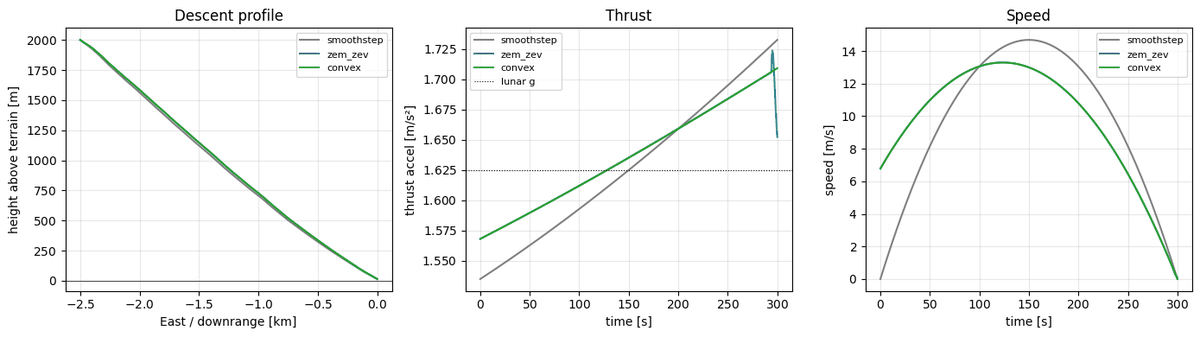

In [5]:
tt = {k: np.array(v.t) for k, v in trajectories.items()}
colors = {"smoothstep": "tab:gray", "zem_zev": "tab:blue", "convex": "tab:green"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for name, tr in trajectories.items():
    r = np.array(tr.r)
    v = np.array(tr.v)
    a = np.array(tr.a)
    thrust = np.linalg.norm(a - np.array([0, 0, -G_MOON]), axis=1)
    alt = r[:, 2] - np.array([terr(e, n) for e, n in r[:, :2]])
    axes[0].plot(r[:, 0] / 1e3, alt, color=colors[name], label=name)
    axes[1].plot(tt[name], thrust, color=colors[name], label=name)
    axes[2].plot(tt[name], np.linalg.norm(v, axis=1), color=colors[name], label=name)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_xlabel("East / downrange [km]")
axes[0].set_ylabel("height above terrain [m]")
axes[0].set_title("Descent profile")
axes[1].axhline(G_MOON, color="k", ls=":", lw=0.8, label="lunar g")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("thrust accel [m/s²]")
axes[1].set_title("Thrust")
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("speed [m/s]")
axes[2].set_title("Speed")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.2 Select a trajectory and run the descent-navigation simulation

Pick one guidance law as the truth trajectory (`GUIDANCE` below) and hand it to the simulation through
`cfg.ref_traj_enu`. `pnt.run_lander_nav` then scatters the crater-landmark map, propagates the LunaNet
relays, and drives the `Lander` agent's hosted `LanderNavApp` EKF — synthesizing noisy IMU, altimeter,
crater bearings, and pseudoranges at each step. (Leaving `ref_traj_enu` unset falls back to the
built-in smoothstep descent.)

In [6]:
GUIDANCE = "zem_zev"  # one of: "smoothstep", "zem_zev", "convex"
ref = trajectories[GUIDANCE]

cfg = pnt.LanderNavConfig()
cfg.seed = 42
cfg.start_epoch_utc = t0_str
cfg.duration_s = T_DESCENT
cfg.dt_s = DT

cfg.site_lat_deg = SITE_LAT
cfg.site_lon_deg = SITE_LON
cfg.dem_half_width_m = HALF_WIDTH_M

# Reference (truth) trajectory from the selected guidance law (ENU, N x 3). This overrides the
# built-in smoothstep descent and sets the epoch count.
cfg.ref_traj_enu = ref.r

# IMU (Kalibr noise model) — representative tactical-grade (LN200S-class)
cfg.accel_noise_density = 3.4e-4
cfg.accel_bias_rw = 1.0e-4
cfg.gyro_noise_density = 3.4e-6
cfg.gyro_bias_rw = 1.0e-6
cfg.accel_bias0 = 1.0e-2
cfg.gyro_bias0 = 5.0e-4

# Radar altimeter
cfg.enable_altimeter = True
cfg.altimeter_sigma_m = 2.0

# Crater-landmark camera (terrain-relative navigation)
cfg.enable_craters = True
cfg.n_craters = 60
cfg.crater_field_radius_m = 3000.0
cfg.camera_fov_deg = 30.0
cfg.max_craters_per_epoch = 6
cfg.crater_sigma_arcsec = 120.0  # ~0.58 mrad bearing noise

# LunaNet: 1 m pseudorange noise, 3 m SISE (1-sigma)
cfg.enable_lunanet = True
cfg.satellites = satellites
cfg.pseudorange_sigma_m = 1.0
cfg.sise_m = 3.0

res = pnt.run_lander_nav(cfg)
N = len(res.time_s)
t = np.array(res.time_s)
print(f"Ran {N} epochs at site {res.site_id}")
print(f"Mean visible LunaNet sats : {np.array(res.n_visible_sat).mean():.2f}")
print(f"Mean tracked craters      : {np.array(res.n_craters).mean():.2f}")
print(f"Final 3D position error   : {np.array(res.pos_err_norm)[-1]:.2f} m")
print(f"Final velocity error      : {np.array(res.vel_err_norm)[-1]:.3f} m/s")

Ran 601 epochs at site Site01
Mean visible LunaNet sats : 3.99
Mean tracked craters      : 1.63
Final 3D position error   : 4.71 m
Final velocity error      : 0.034 m/s


## 4. Results

### 4.1 The descent trajectory over the terrain

The truth and estimated 3-D descent paths, above the shaded DEM, with the synthetic crater-landmark
map marked on the surface.

In [7]:
truth = np.array(res.traj_enu_truth) / 1e3  # km, (E, N, U)
est = np.array(res.traj_enu_est) / 1e3
craters = np.array(res.crater_enu) / 1e3

Xc = (dem.x - res.dem_center_x) / 1e3
Yc = (dem.y - res.dem_center_y) / 1e3
Z = dem.elevation / 1e3
crater_z = np.array(
    [
        dem.get_elevation(cx, cy) / 1e3
        for cx, cy in zip(
            res.dem_center_x + craters[:, 0] * 1e3,
            res.dem_center_y + craters[:, 1] * 1e3,
        )
    ]
)

fig = go.Figure()
fig.add_surface(
    x=Xc,
    y=Yc,
    z=Z,
    colorscale="earth",
    opacity=0.72,
    showscale=False,
    name="terrain",
    hovertemplate="E=%{x:.2f} km<br>N=%{y:.2f} km<br>U=%{z:.2f} km<extra></extra>",
)
fig.add_scatter3d(
    x=craters[:, 0],
    y=craters[:, 1],
    z=crater_z,
    mode="markers",
    marker=dict(color="saddlebrown", size=3),
    name="crater landmarks",
)
fig.add_scatter3d(
    x=truth[:, 0],
    y=truth[:, 1],
    z=truth[:, 2],
    mode="lines",
    line=dict(color="royalblue", width=6),
    name="truth descent",
)
fig.add_scatter3d(
    x=est[:, 0],
    y=est[:, 1],
    z=est[:, 2],
    mode="lines",
    line=dict(color="crimson", width=4, dash="dash"),
    name="EKF estimate",
)
fig.add_scatter3d(
    x=[truth[0, 0]],
    y=[truth[0, 1]],
    z=[truth[0, 2]],
    mode="markers",
    marker=dict(color="black", size=5),
    name="start",
)
fig.add_scatter3d(
    x=[truth[-1, 0]],
    y=[truth[-1, 1]],
    z=[truth[-1, 2]],
    mode="markers",
    marker=dict(color="limegreen", size=8, symbol="diamond"),
    name="touchdown",
)
fig.update_layout(
    title="Lunar lander powered descent (ENU about tile center)",
    width=760,
    height=620,
    margin=dict(l=10, r=10, t=45, b=10),
    scene=dict(
        xaxis_title="East [km]",
        yaxis_title="North [km]",
        zaxis_title="Up [km]",
        aspectmode="data",
    ),
    legend=dict(x=0.02, y=0.98),
)
pnt.plot.set_view(fig, azimuth=-120, elevation=22, zoom=1.45)
embed_plotly(fig, "ex11_descent")

[doc-asset] plots/ex11_descent.html  (6163 kB)  ->  https://stanford-navlab.github.io/lupnt-doc-assets/plots/ex11_descent.html


### 4.2 Ground track and crater visibility

Looking straight down: the descent ground track over the DEM, the crater map, and — shaded along the
track — how many craters the down-looking camera sees. The footprint (and thus the crater count)
shrinks as the lander descends, so terrain-relative fixes fade out near touchdown.

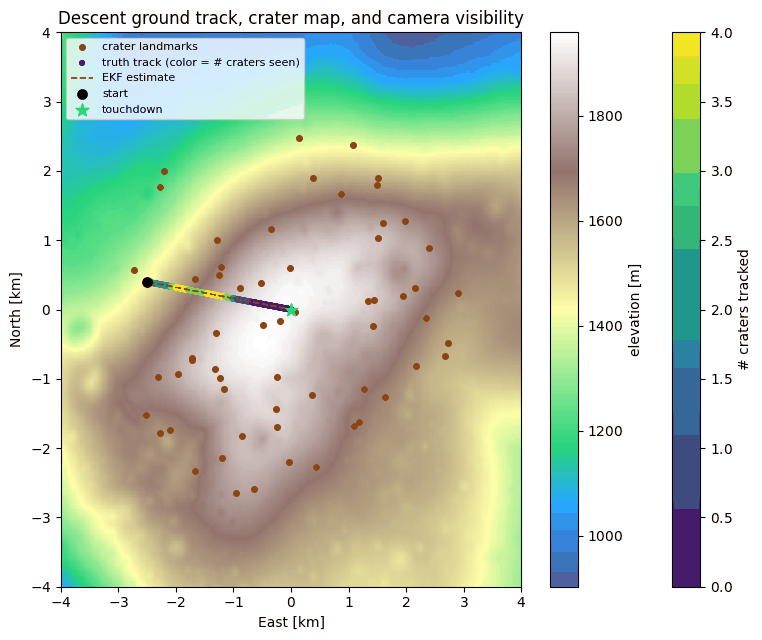

In [8]:
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.pcolormesh(Xc, Yc, dem.elevation, cmap="terrain", shading="auto", alpha=0.85)
ax.scatter(
    craters[:, 0],
    craters[:, 1],
    c="saddlebrown",
    s=16,
    label="crater landmarks",
    zorder=3,
)
sc = ax.scatter(
    truth[:, 0],
    truth[:, 1],
    c=np.array(res.n_craters),
    cmap="viridis",
    s=12,
    zorder=4,
    label="truth track (color = # craters seen)",
)
ax.plot(est[:, 0], est[:, 1], "r--", lw=1.2, zorder=5, label="EKF estimate")
ax.scatter(truth[0, 0], truth[0, 1], c="k", s=45, zorder=6, label="start")
ax.scatter(
    truth[-1, 0], truth[-1, 1], c="lime", s=90, marker="*", zorder=6, label="touchdown"
)
ax.set_xlabel("East [km]")
ax.set_ylabel("North [km]")
ax.set_title("Descent ground track, crater map, and camera visibility")
fig.colorbar(sc, ax=ax, label="# craters tracked")
fig.colorbar(im, ax=ax, label="elevation [m]")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 4.3 Altitude profile and altimeter performance

Height above terrain, truth vs. estimate, and the altitude error over the descent. The nadir altimeter
keeps the vertical channel tight all the way to touchdown.

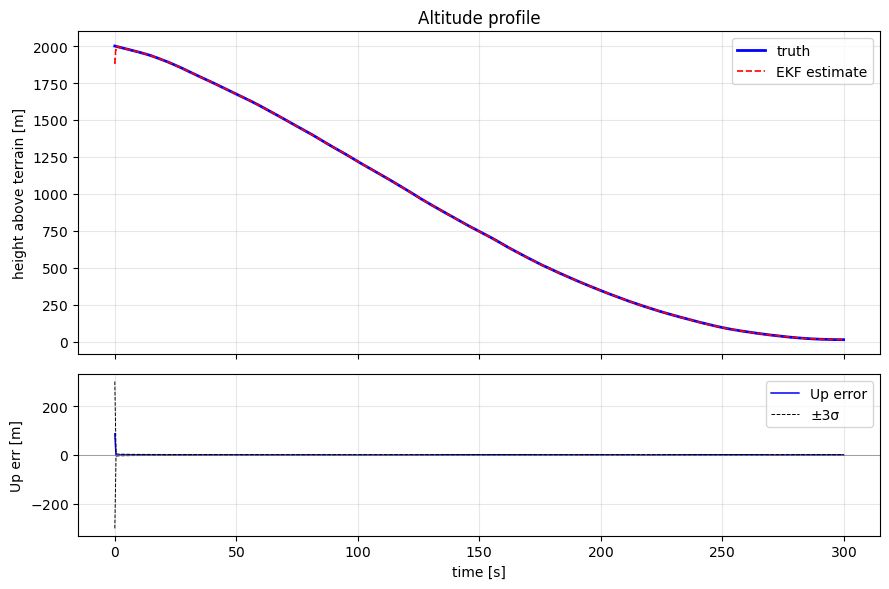

In [9]:
alt_truth = np.array(res.alt_truth)
alt_est = np.array(res.alt_est)
fig, (a1, a2) = plt.subplots(
    2, 1, figsize=(9, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
a1.plot(t, alt_truth, "b-", lw=2, label="truth")
a1.plot(t, alt_est, "r--", lw=1.2, label="EKF estimate")
a1.set_ylabel("height above terrain [m]")
a1.grid(alpha=0.3)
a1.legend()
a1.set_title("Altitude profile")
up_err = np.array(res.pos_err_enu)[:, 2]
up_sig = np.array(res.pos_sigma_enu)[:, 2]
a2.plot(t, up_err, "b-", lw=1.1, label="Up error")
a2.plot(t, 3 * up_sig, "k--", lw=0.7, label="±3σ")
a2.plot(t, -3 * up_sig, "k--", lw=0.7)
a2.axhline(0, color="gray", lw=0.5)
a2.set_xlabel("time [s]")
a2.set_ylabel("Up err [m]")
a2.grid(alpha=0.3)
a2.legend()
plt.tight_layout()
plt.show()

### 4.4 Position error vs. filter 3σ (East / North / Up)

The estimate error against the filter's own 3σ envelope. Horizontal (East downrange, North crossrange)
is anchored by crater bearings during the approach and by LunaNet through terminal descent; vertical is
pinned by the altimeter. The residual downrange floor is set by the 3 m LunaNet signal-in-space error
(modeled per-epoch, so the filter's covariance is mildly optimistic there — see the note in ex10).

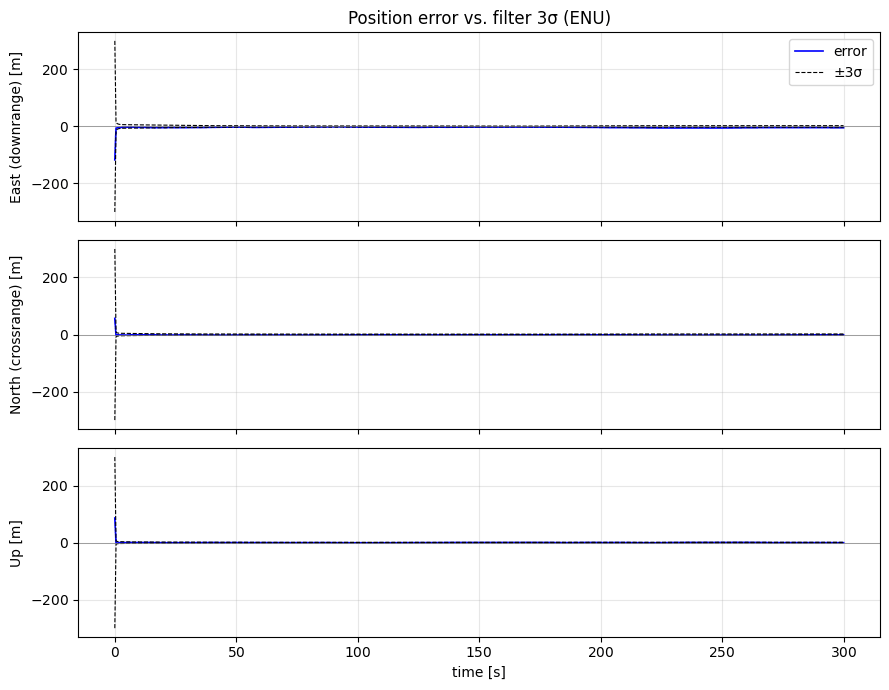

In [10]:
err = np.array(res.pos_err_enu)
sig = np.array(res.pos_sigma_enu)
labels = ["East (downrange)", "North (crossrange)", "Up"]
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, err[:, i], "b-", lw=1.2, label="error")
    ax.plot(t, 3 * sig[:, i], "k--", lw=0.8, label="±3σ")
    ax.plot(t, -3 * sig[:, i], "k--", lw=0.8)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_ylabel(f"{labels[i]} [m]")
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("time [s]")
axes[0].set_title("Position error vs. filter 3σ (ENU)")
plt.tight_layout()
plt.show()

### 4.5 Sensor visibility and clock estimation

Visible LunaNet satellites and tracked craters over the descent (top), and the receiver clock-bias
error made observable by the LunaNet pseudoranges (bottom).

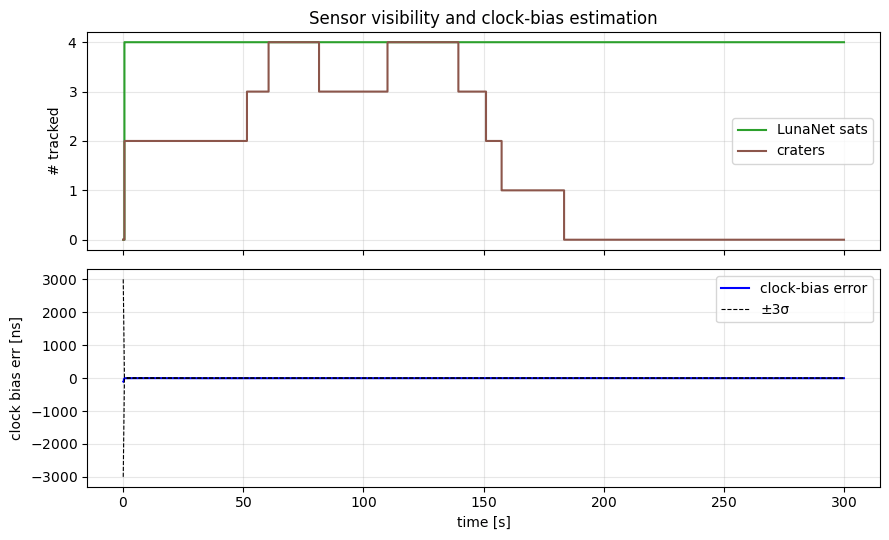

In [11]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
a1.step(t, res.n_visible_sat, where="post", color="tab:green", label="LunaNet sats")
a1.step(t, res.n_craters, where="post", color="tab:brown", label="craters")
a1.set_ylabel("# tracked")
a1.grid(alpha=0.3)
a1.legend()
a1.set_title("Sensor visibility and clock-bias estimation")
cb_err = np.array(res.clock_bias_err) * 1e9
cb_sig = np.array(res.clock_bias_sigma) * 1e9
a2.plot(t, cb_err, "b-", label="clock-bias error")
a2.plot(t, 3 * cb_sig, "k--", lw=0.8, label="±3σ")
a2.plot(t, -3 * cb_sig, "k--", lw=0.8)
a2.set_xlabel("time [s]")
a2.set_ylabel("clock bias err [ns]")
a2.grid(alpha=0.3)
a2.legend()
plt.tight_layout()
plt.show()

### 4.6 IMU bias estimation

The strapdown filter estimates the accelerometer and gyroscope biases online. Roll/pitch accel biases
are observable through the gravity direction sensed by the accelerometer; the vigorous descent
dynamics and the crater/altimeter aiding make the remaining components observable too.

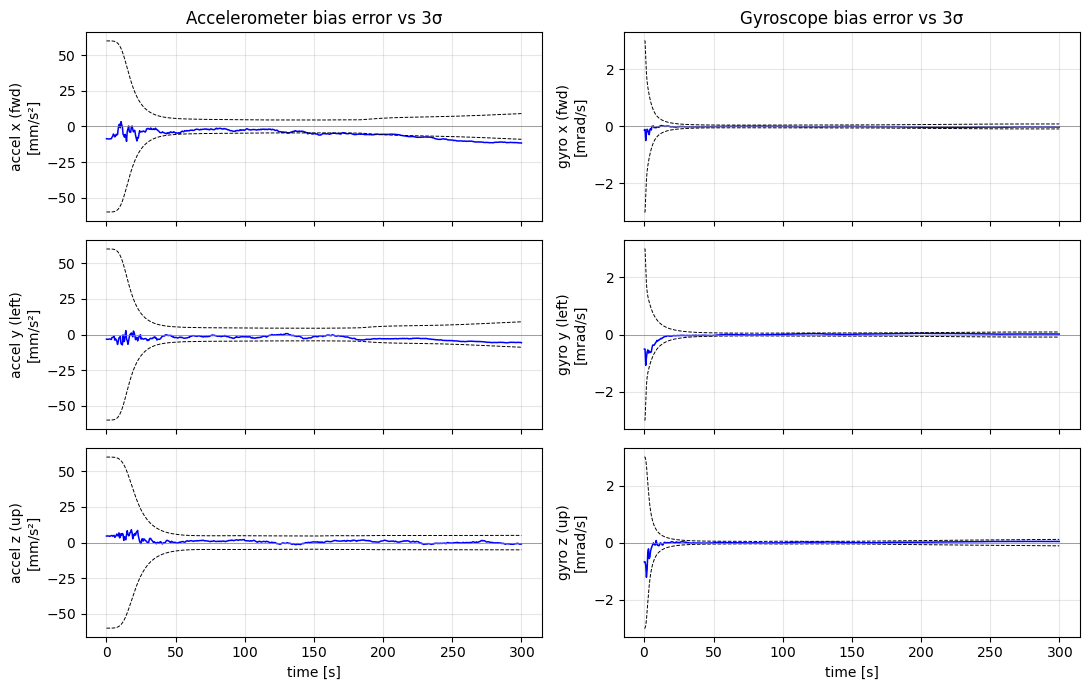

In [12]:
ba_err = np.array(res.accel_bias_err) * 1e3  # mm/s^2
ba_sig = np.array(res.accel_bias_sigma) * 1e3
bg_err = np.array(res.gyro_bias_err) * 1e3  # mrad/s
bg_sig = np.array(res.gyro_bias_sigma) * 1e3
axlab = ["x (fwd)", "y (left)", "z (up)"]

fig, axes = plt.subplots(3, 2, figsize=(11, 7), sharex=True)
for i in range(3):
    a = axes[i, 0]
    a.plot(t, ba_err[:, i], "b-", lw=1.1)
    a.plot(t, 3 * ba_sig[:, i], "k--", lw=0.7)
    a.plot(t, -3 * ba_sig[:, i], "k--", lw=0.7)
    a.axhline(0, color="gray", lw=0.5)
    a.set_ylabel(f"accel {axlab[i]}\n[mm/s²]")
    a.grid(alpha=0.3)
    g = axes[i, 1]
    g.plot(t, bg_err[:, i], "b-", lw=1.1)
    g.plot(t, 3 * bg_sig[:, i], "k--", lw=0.7)
    g.plot(t, -3 * bg_sig[:, i], "k--", lw=0.7)
    g.axhline(0, color="gray", lw=0.5)
    g.set_ylabel(f"gyro {axlab[i]}\n[mrad/s]")
    g.grid(alpha=0.3)
axes[0, 0].set_title("Accelerometer bias error vs 3σ")
axes[0, 1].set_title("Gyroscope bias error vs 3σ")
axes[-1, 0].set_xlabel("time [s]")
axes[-1, 1].set_xlabel("time [s]")
plt.tight_layout()
plt.show()

### 4.7 Attitude estimation

Attitude error (rotation vector, body axes) vs. the filter 3σ. Roll/pitch are observed via gravity;
**yaw is made observable by the crater bearings**, which depend directly on the body attitude — a key
benefit of terrain-relative navigation over range-only aiding.

Because this is a **MEKF**, the orientation itself is estimated as a **unit quaternion** `q_b2n`
(injected multiplicatively and reset each update); the error plot below is that quaternion's
3-parameter multiplicative error `δθ`. The second panel shows the estimated quaternion components,
which stay unit-norm by construction.

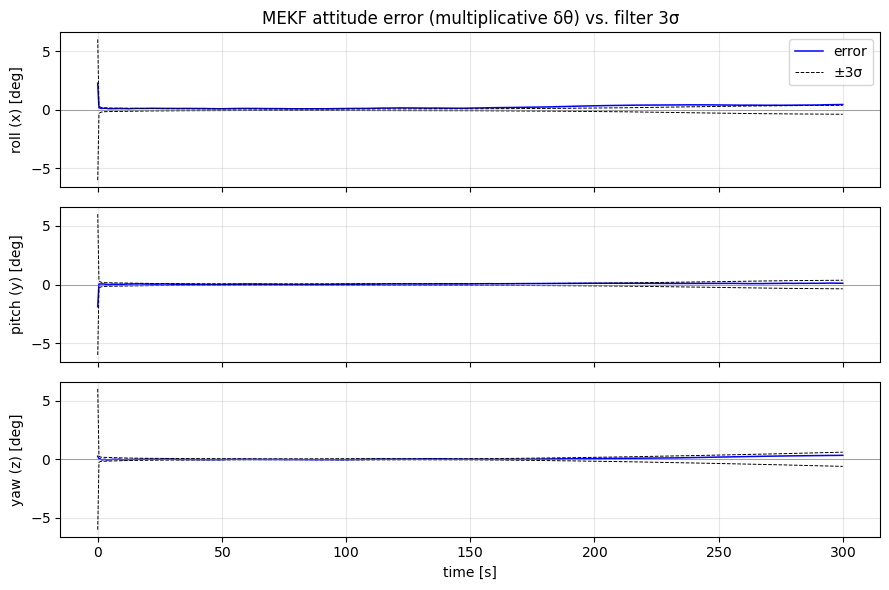

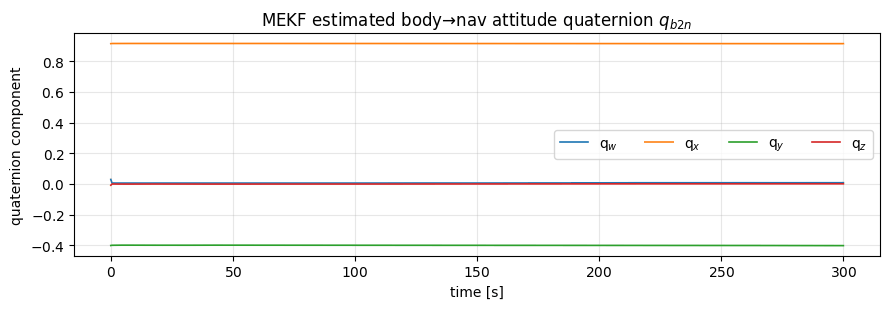

quaternion norm over the run: min=1.000000000, max=1.000000000 (unit by construction)


In [13]:
ae = np.array(res.att_err_deg)
asig = np.array(res.att_sigma_deg)
rp = ["roll (x)", "pitch (y)", "yaw (z)"]
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, ae[:, i], "b-", lw=1.1, label="error")
    ax.plot(t, 3 * asig[:, i], "k--", lw=0.7, label="±3σ")
    ax.plot(t, -3 * asig[:, i], "k--", lw=0.7)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_ylabel(f"{rp[i]} [deg]")
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("time [s]")
axes[0].set_title("MEKF attitude error (multiplicative δθ) vs. filter 3σ")
plt.tight_layout()
plt.show()

# MEKF nominal attitude quaternion q_b2n = [w, x, y, z], unit-norm by construction.
quat = np.array(res.att_quat_est)
qnorm = np.linalg.norm(quat, axis=1)
fig, ax = plt.subplots(figsize=(9, 3.2))
for i, lab in enumerate("wxyz"):
    ax.plot(t, quat[:, i], lw=1.2, label=f"q$_{lab}$")
ax.set_xlabel("time [s]")
ax.set_ylabel("quaternion component")
ax.set_title("MEKF estimated body→nav attitude quaternion $q_{b2n}$")
ax.grid(alpha=0.3)
ax.legend(ncol=4, loc="center right")
plt.tight_layout()
plt.show()
print(
    f"quaternion norm over the run: min={qnorm.min():.9f}, max={qnorm.max():.9f} (unit by construction)"
)

### 4.8 What does each sensor buy? (ablation study)

Re-run the descent turning each aiding source off in turn, and compare the mid-descent horizontal
error (approach phase, where craters dominate), the terminal horizontal error (last 10 s), and the
terminal vertical error. Each sensor covers a distinct failure mode.

scenario          mid-descent H   terminal H  terminal Up
all sensors              3.04 m       4.59 m       0.11 m
no craters               5.96 m       5.26 m       0.11 m
no altimeter             3.11 m       3.72 m       1.91 m
no LunaNet               1.07 m      16.03 m       1.51 m


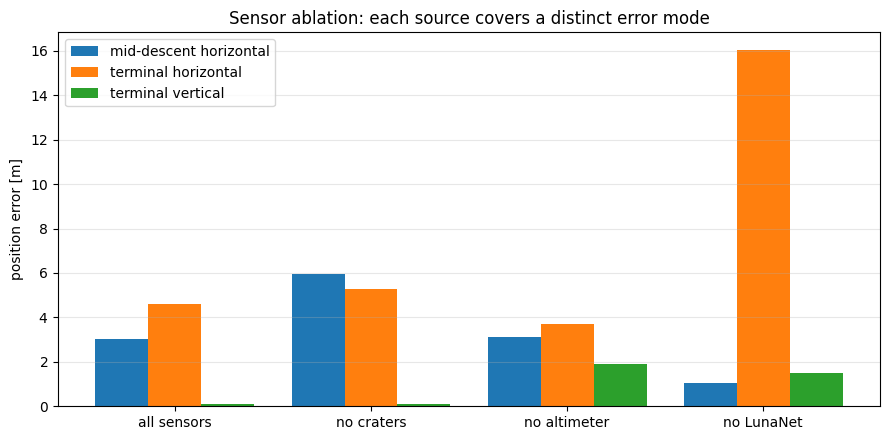

In [14]:
def run(**overrides):
    c = pnt.LanderNavConfig()
    for attr in (
        "seed",
        "start_epoch_utc",
        "duration_s",
        "dt_s",
        "site_lat_deg",
        "site_lon_deg",
        "dem_half_width_m",
        "descent_start_east_m",
        "descent_start_north_m",
        "descent_end_east_m",
        "descent_end_north_m",
        "descent_start_alt_m",
        "descent_end_alt_m",
        "accel_noise_density",
        "accel_bias_rw",
        "gyro_noise_density",
        "gyro_bias_rw",
        "accel_bias0",
        "gyro_bias0",
        "altimeter_sigma_m",
        "n_craters",
        "crater_field_radius_m",
        "camera_fov_deg",
        "max_craters_per_epoch",
        "crater_sigma_arcsec",
        "pseudorange_sigma_m",
        "sise_m",
    ):
        setattr(c, attr, getattr(cfg, attr))
    c.satellites = satellites
    c.ref_traj_enu = (
        cfg.ref_traj_enu
    )  # same selected guidance trajectory as the main run
    for k, v in overrides.items():
        setattr(c, k, v)
    r = pnt.run_lander_nav(c)
    pe = np.array(r.pos_err_enu)
    n = len(pe)
    mid = slice(int(0.25 * n), int(0.75 * n))
    midH = np.linalg.norm(pe[mid, :2], axis=1).mean()
    finH = np.linalg.norm(pe[-20:, :2], axis=1).mean()
    finU = np.abs(pe[-20:, 2]).mean()
    return midH, finH, finU


scenarios = {
    "all sensors": dict(),
    "no craters": dict(enable_craters=False),
    "no altimeter": dict(enable_altimeter=False),
    "no LunaNet": dict(enable_lunanet=False),
}
rows = {name: run(**ov) for name, ov in scenarios.items()}
print(
    f"{'scenario':16s} {'mid-descent H':>14s} {'terminal H':>12s} {'terminal Up':>12s}"
)
for name, (midH, finH, finU) in rows.items():
    print(f"{name:16s} {midH:12.2f} m {finH:10.2f} m {finU:10.2f} m")

names = list(rows.keys())
midH = [rows[n][0] for n in names]
finH = [rows[n][1] for n in names]
finU = [rows[n][2] for n in names]
x = np.arange(len(names))
w = 0.27
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w, midH, w, label="mid-descent horizontal")
ax.bar(x, finH, w, label="terminal horizontal")
ax.bar(x + w, finU, w, label="terminal vertical")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("position error [m]")
ax.grid(alpha=0.3, axis="y")
ax.set_title("Sensor ablation: each source covers a distinct error mode")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Summary

This example used LuPNT to run a complete powered-descent navigation tutorial:

- guidance generated a reference descent trajectory in local ENU coordinates;
- the lander app fused IMU, altimeter, crater-bearing, and LunaNet pseudorange measurements;
- the MEKF kept attitude on the unit-quaternion manifold while estimating a minimal attitude error;
- sensor ablations showed which measurement source supports each navigation channel.

A natural next step is to replace the synthetic crater map with an image-processing front end, or to couple this estimator to a closed-loop guidance and control simulation.